In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

In [2]:
# 1. Load dataset
# wdbc.data does not have headers, so we define them
columns = ["ID", "Diagnosis"] + [f"feature_{i}" for i in range(1, 31)]
data = pd.read_csv("wdbc.data", header=None, names=columns)

In [3]:
# 2. Prepare features and target
X = data.drop(["ID", "Diagnosis"], axis=1)
y = data["Diagnosis"].map({"M": 1, "B": 0})  # Malignant=1, Benign=0

In [4]:

# 4. Preprocessor (scaling not needed for trees, but kept for pipeline consistency)
num_features = X.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[("scale", StandardScaler(), num_features)],
    remainder="drop"
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# 5. Pipeline
pipe = Pipeline([
    ("prep", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=42))
])


In [7]:
# 6. Hyperparameter grid
param_grid = {
    "clf__criterion": ["gini", "entropy", "log_loss"],
    "clf__max_depth": [3, 5, 10],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# GridSearchCV with Accuracy only
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",   # ✅ Only accuracy
    refit=True,           # Refits using accuracy
    n_jobs=-1
)
grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__criterion': ['gini', 'entropy', ...], 'clf__max_depth': [3, 5, ...], 'clf__min_samples_leaf': [1, 2, ...], 'clf__min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('scale', ...)]"


In [11]:
# Save results to DataFrame
dt_results = pd.DataFrame(grid.cv_results_)

# Keep ALL hyperparameters + accuracy
dt_table = dt_results[[
    "param_clf__criterion",
    "param_clf__max_depth",
    "param_clf__min_samples_split",
    "param_clf__min_samples_leaf",
    "mean_test_score"
]]

# Rename columns
dt_table = dt_table.rename(columns={
    "param_clf__criterion": "criterion",
    "param_clf__max_depth": "max_depth",
    "param_clf__min_samples_split": "min_samples_split",
    "param_clf__min_samples_leaf": "min_samples_leaf",
    "mean_test_score": "Accuracy"
})

In [12]:
# Sort by Accuracy and take Top 5
top5 = dt_table.sort_values(by="Accuracy", ascending=False).head(5)
print("\nTop 5 Results (by Accuracy):")
print(top5)



Top 5 Results (by Accuracy):
   criterion  max_depth  min_samples_split  min_samples_leaf  Accuracy
41   entropy          5                 10                 2  0.936264
68  log_loss          5                 10                 2  0.936264
50   entropy         10                 10                 2  0.934066
77  log_loss         10                 10                 2  0.934066
65  log_loss          5                 10                 1  0.929670


In [14]:
# Best parameters
best_params = grid.best_params_
best_acc = grid.best_score_

# Convert to DataFrame for clean table display
best_table = pd.DataFrame([best_params])
best_table["Best Accuracy"] = best_acc

print("\nBest Hyperparameters:")
print(best_table)


Best Hyperparameters:
  clf__criterion  clf__max_depth  clf__min_samples_leaf  \
0        entropy               5                      2   

   clf__min_samples_split  Best Accuracy  
0                      10       0.936264  


In [15]:
# 8. Evaluate on test set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [16]:

print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1:", f1_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))


Test Accuracy: 0.9649122807017544
Test Precision: 1.0
Test Recall: 0.9047619047619048
Test F1: 0.95
Test ROC AUC: 0.9743716931216931


/tmp/ipykernel_7162/1817741554.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="coolwarm")


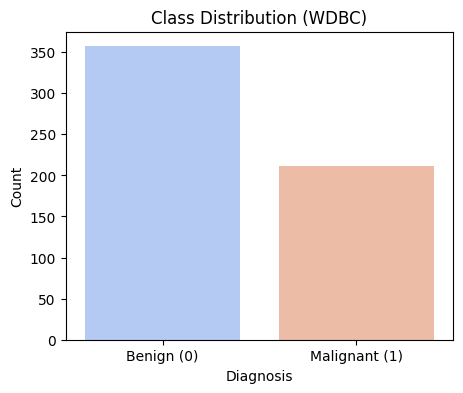

/tmp/ipykernel_7162/1817741554.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette="viridis")


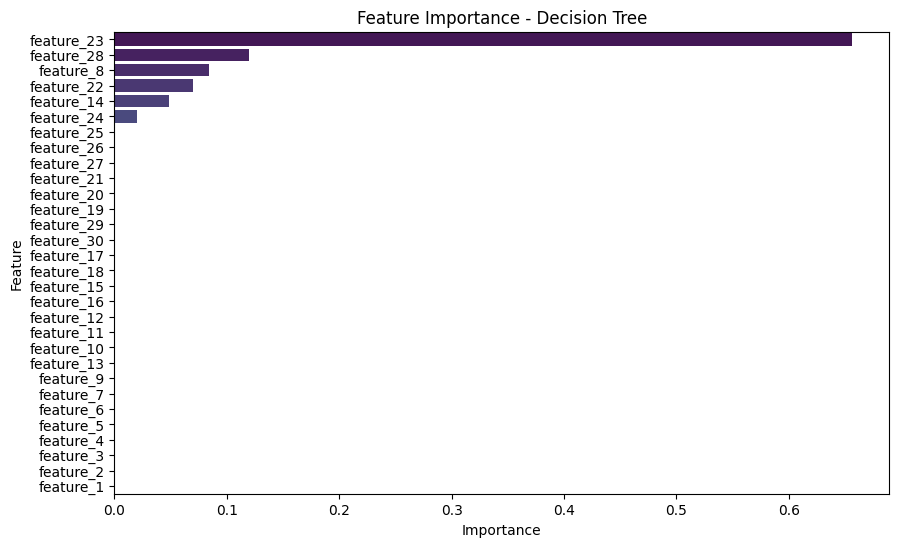

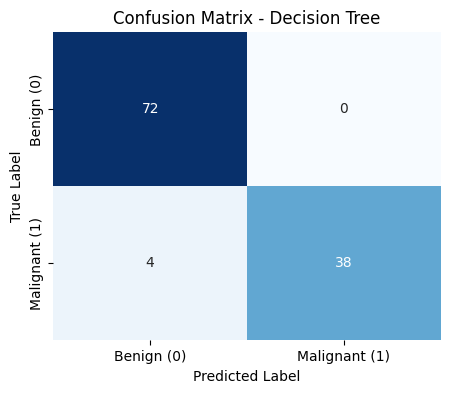

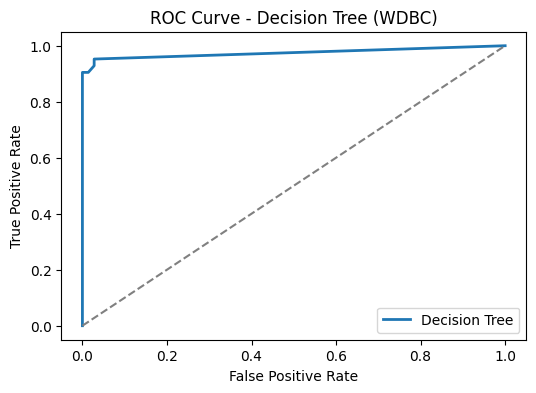

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ---- Class distribution ----
plt.figure(figsize=(5,4))
sns.countplot(x=y, palette="coolwarm")
plt.xticks([0,1], ["Benign (0)", "Malignant (1)"])
plt.title("Class Distribution (WDBC)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

# ---- Feature importance (from Decision Tree) ----
best_clf = best_model.named_steps["clf"]
importances = best_clf.feature_importances_
features = X.columns

# Sort feature importances
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=features[indices], palette="viridis")
plt.title("Feature Importance - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Benign (0)", "Malignant (1)"],
            yticklabels=["Benign (0)", "Malignant (1)"])
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ---- ROC Curve (already included) ----
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="Decision Tree", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree (WDBC)")
plt.legend()
plt.show()

In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Best Decision Tree with tuned hyperparameters
best_dt = DecisionTreeClassifier(
    criterion=grid.best_params_['clf__criterion'],
    max_depth=grid.best_params_['clf__max_depth'],
    min_samples_split=grid.best_params_['clf__min_samples_split'],
    min_samples_leaf=grid.best_params_['clf__min_samples_leaf'],
    random_state=42
)

# Pipeline with preprocessing
pipe_cv = Pipeline([
    ("prep", preprocessor),
    ("clf", best_dt)
])

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracy = cross_val_score(pipe_cv, X, y, cv=cv, scoring="accuracy")

# Print each fold's accuracy
for i, acc in enumerate(cv_accuracy, 1):
    print(f"Fold {i} Accuracy: {acc:.4f}")

# Print average accuracy
print(f"Average 5-Fold CV Accuracy: {cv_accuracy.mean():.4f}")

Fold 1 Accuracy: 0.9123
Fold 2 Accuracy: 0.8860
Fold 3 Accuracy: 0.9386
Fold 4 Accuracy: 0.9474
Fold 5 Accuracy: 0.9469
Average 5-Fold CV Accuracy: 0.9262
